In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("/mnt/f/lung.csv")

In [4]:
data["Diagnosis"] = data["Diagnosis"].map({"Healthy":0, "Cancer":1})

In [5]:
X = data.drop(["Patient_ID","Diagnosis"], axis=1)

In [6]:
y = data["Diagnosis"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
pred = model.predict(X_test)


In [10]:
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


Accuracy: 1.0
           Sensor  Importance
7              S6        0.11
10             S9        0.11
9              S8        0.10
14  Alkane_Sensor        0.08
2              S1        0.07
4              S3        0.07
13            S12        0.07
1          Gender        0.06
8              S7        0.06
11            S10        0.06
0             Age        0.05
3              S2        0.05
5              S4        0.04
6              S5        0.04
12            S11        0.03


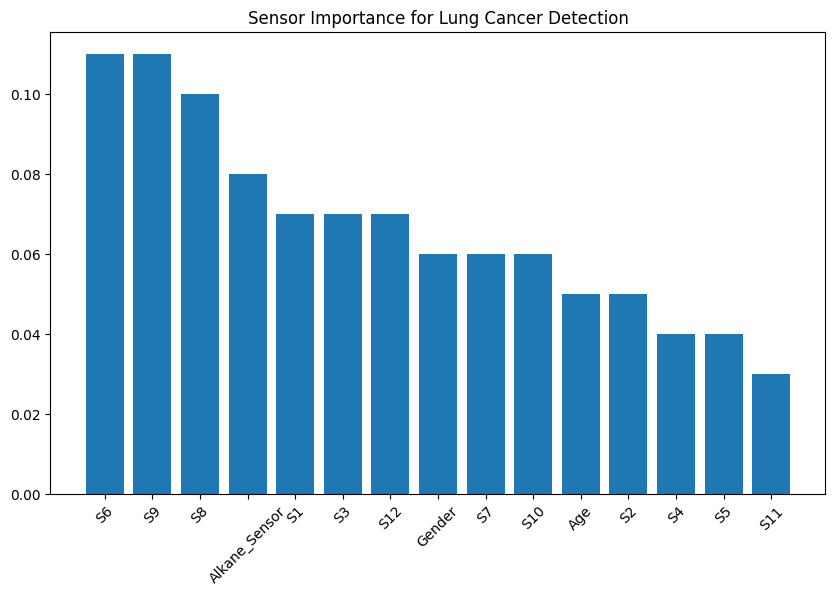

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("/mnt/f/lung.csv")

# Convert labels
data["Diagnosis"] = data["Diagnosis"].map({"Healthy":0, "Cancer":1})

# Features
X = data.drop(["Patient_ID","Diagnosis"], axis=1)

# Target
y = data["Diagnosis"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))

# Feature importance
importance = model.feature_importances_

# Create dataframe
features = pd.DataFrame({
    "Sensor": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(features)

# Plot importance
plt.figure(figsize=(10,6))
plt.bar(features["Sensor"], features["Importance"])
plt.xticks(rotation=45)
plt.title("Sensor Importance for Lung Cancer Detection")
plt.show()

Accuracy: 1.0


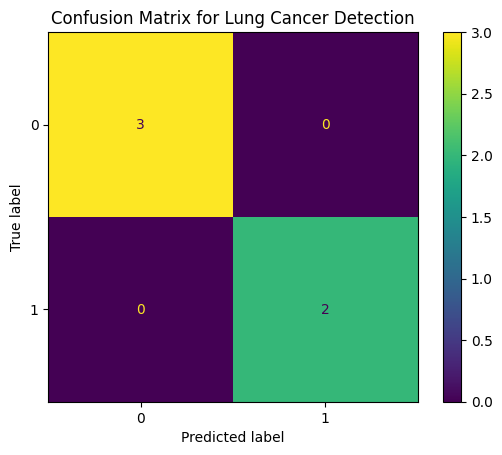

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
data = pd.read_csv("/mnt/f/lung.csv")

# Convert labels
data["Diagnosis"] = data["Diagnosis"].map({"Healthy":0, "Cancer":1})

# Features
X = data.drop(["Patient_ID","Diagnosis"], axis=1)

# Target
y = data["Diagnosis"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, pred))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix for Lung Cancer Detection")
plt.show()

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("/mnt/f/lung.csv")

# Convert labels
data["Diagnosis"] = data["Diagnosis"].map({"Healthy":0, "Cancer":1})

# Features
X = data.drop(["Patient_ID","Diagnosis"], axis=1)

# Target
y = data["Diagnosis"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, pred))

Decision Tree Accuracy: 1.0


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Load dataset
data = pd.read_csv("/mnt/f/lung.csv")

# Convert diagnosis labels
data["Diagnosis"] = data["Diagnosis"].map({"Healthy":0, "Cancer":1})

# Features
X = data.drop(["Patient_ID","Diagnosis"], axis=1)

# Target
y = data["Diagnosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models to test
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Train and evaluate
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    
    print(name, "Accuracy:", acc)

Random Forest Accuracy: 1.0
Decision Tree Accuracy: 0.8
SVM Accuracy: 1.0
Logistic Regression Accuracy: 1.0
KNN Accuracy: 1.0
Gradient Boosting Accuracy: 1.0


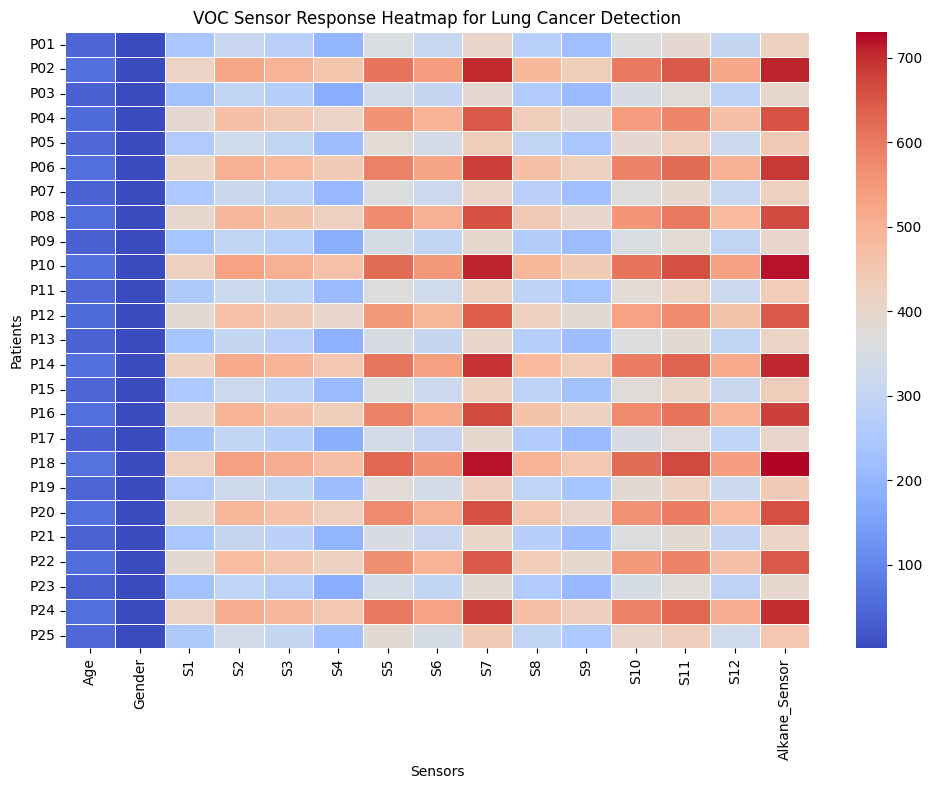

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("/mnt/f/lung.csv")

# Remove non-sensor columns
sensor_data = data.drop(["Patient_ID"], axis=1)

# Set patient ID as index
sensor_data.index = data["Patient_ID"]

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(sensor_data.drop("Diagnosis", axis=1),
            cmap="coolwarm",
            linewidths=0.5)

plt.title("VOC Sensor Response Heatmap for Lung Cancer Detection")
plt.xlabel("Sensors")
plt.ylabel("Patients")

plt.show()

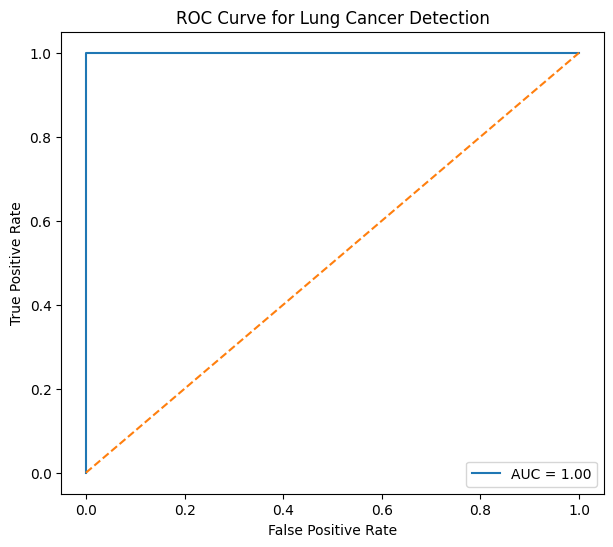

In [9]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Lung Cancer Detection")

plt.legend(loc="lower right")
plt.show()

          Feature  Importance
7              S6    0.298665
1          Gender    0.235685
2              S1    0.104092
11            S10    0.099694
6              S5    0.092774
10             S9    0.054824
4              S3    0.044042
13            S12    0.019538
0             Age    0.018887
14  Alkane_Sensor    0.016612
3              S2    0.012784
9              S8    0.002141
12            S11    0.000258
8              S7    0.000005
5              S4    0.000000


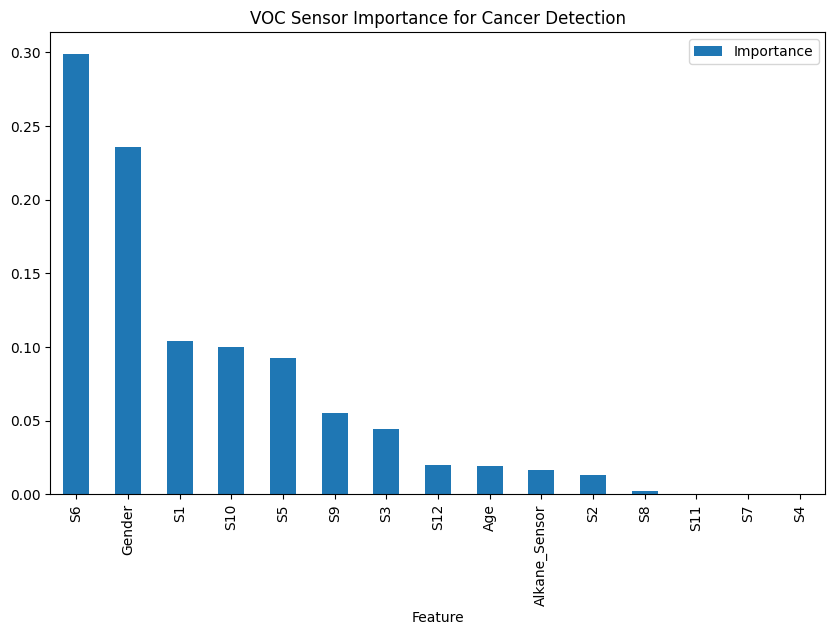

In [10]:
import pandas as pd

importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature":features,
    "Importance":importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

importance_df.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,6),
    title="VOC Sensor Importance for Cancer Detection"
)

plt.show()

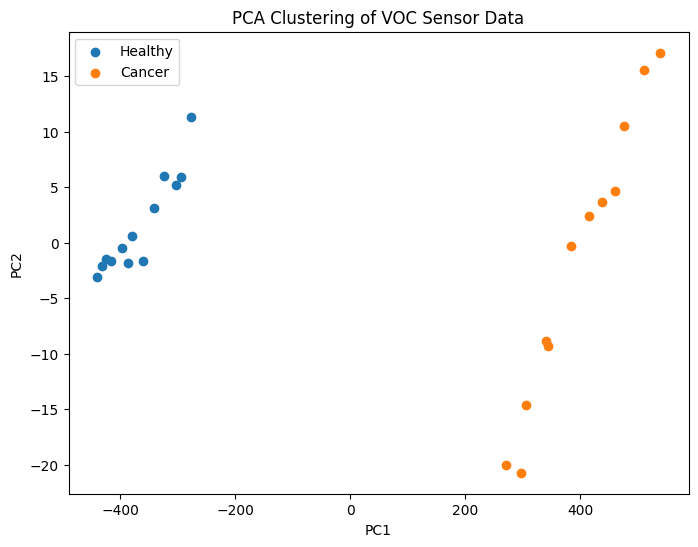

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load dataset
data = pd.read_csv("/mnt/f/lung.csv")

# Convert diagnosis labels
data["Diagnosis"] = data["Diagnosis"].map({"Healthy":0, "Cancer":1})

# Features
X = data.drop(["Patient_ID","Diagnosis"], axis=1)

# Target
y = data["Diagnosis"]

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(8,6))

plt.scatter(X_pca[y==0,0], X_pca[y==0,1], label="Healthy")
plt.scatter(X_pca[y==1,0], X_pca[y==1,1], label="Cancer")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Clustering of VOC Sensor Data")

plt.legend()
plt.show()